# ML_Assignment_1

## Bike Sharing Demand Prediction Challenge

### Student details

* **Name**:_________*Pankaj Singh Rawat*
* **Roll Number**:__*2025ac05533*
* **Course**:_______*BITS M.Tech (AI&ML)*
* **Subject**:______*Machine Learning / ML*
* **Assignment**:___*Assignment 1*

**Objective:** Objective of this assignment is to predict the number of bike rentals per hour using weather, time, and seasonal data.

**Target column:** count (the number of bike rentals per hour)

## Index

*    1. [Load Data](#section_1)
*    2. [Data pre-processing](#section_2)
*    3. [Exploratory Data Analysis (EDA) with Visualization](#section_3)
        *   [3A. General descriptive anlaysis of dataset](#section_3a)
        *   [3B. Distribution of target variable (`count`)](#section_3b)
        *   [3C. Relationship between categorical columns and target variable (`count`)](#section_3c)
        *   [3D. Relationship between numerical columns and target variable (`count`)](#section_3d)
        *   [3E. Check correlation among features](#section_3e)
        *   [3F. Observation and summary](#section_3f)
*    4. [Feature Selection and Engineering](#section_4)
*    5. [Regression Models (Model Evaluations and Selection)](#section_5)
*    6. [Test data](#section_6)
*    7. [Predictions](#section_7)
*    8. [Assignment Questions (Q&A)](#section_8)

## <a id='section_1'>1. Load Data</a> 

In [1]:
import pandas as pd
pd.set_option('display.max_columns', 50)

train_data = pd.read_csv('bike_train.csv')
train_data.head()

,datetime,season,holiday,workingday,weather,temp,atemp,humidity,windspeed,casual,registered,count
0,2012-07-15 7:00:00,3,0,0,1,28.70000,33.335000,79,6.003200,17,30,47
1,2012-08-14 15:00:00,3,0,1,1,33.62000,37.880000,46,15.001300,84,199,283
2,2011-02-06 6:00:00,1,0,0,1,10.66000,12.880000,60,15.001300,0,1,1
3,2012-05-06 17:00:02,2,0,0,2,26.42506,30.566166,61,9.512288,198,330,531
4,2012-01-09 2:00:00,1,0,1,1,9.84000,12.120000,56,8.998100,2,3,5


#### **About Data**

* **datetime**: Date and time corresponding to each observation. It includes information such as year, month, day, hour, minute, and second.

* **season**: Season during which the observation was recorded.

* **holiday**: Indicates whether the day is a holiday or not.

    - 1 = Holiday

    - 0 = No holiday

* **workingday**: Indicates whether the day is a working day.

    - 1 = Working day

    - 0 = Weekend or holiday

* **weather**: Weather condition during the observation.

* **temp**: Actual temperature in Celsius.

* **atemp**: "Feels like" temperature in Celsius.

* **humidity**: Relative humidity level.

* **windspeed**: Wind speed recorded during the observation.

* **casual**: Number of bike rentals by casual users.

* **registered**: Number of bike rentals by registered users.

* **count**: Total number of bike rentals. This is the target variable to be predicted.

  

## <a id='section_2'>2. Data pre-processing</a>

In [2]:
## Remove unnecessary columns
train_data = train_data.drop(columns=['casual','registered'])

In [3]:
## Exploding datetime column into year, month, day, and hour for better feature engineering and model performance.
train_data['datetime'] = pd.to_datetime(train_data['datetime'],dayfirst=True)
train_data['year'] = train_data['datetime'].dt.year
train_data['month'] = train_data['datetime'].dt.month
train_data['day'] = train_data['datetime'].dt.day
train_data['hour'] = train_data['datetime'].dt.hour

/var/folders/06/hkr693g11w5664zqwdb59_2r0000gn/T/ipykernel_11407/3178518018.py:2: UserWarning: Parsing dates in %Y-%m-%d %H:%M:%S format when dayfirst=True was specified. Pass `dayfirst=False` or specify a format to silence this warning.
  train_data['datetime'] = pd.to_datetime(train_data['datetime'],dayfirst=True)


In [4]:
## Final form of the training data after preprocessing
train_data.head()

,datetime,season,holiday,workingday,weather,temp,atemp,humidity,windspeed,count,year,month,day,hour
0,2012-07-15 07:00:00,3,0,0,1,28.70000,33.335000,79,6.003200,47,2012,7,15,7
1,2012-08-14 15:00:00,3,0,1,1,33.62000,37.880000,46,15.001300,283,2012,8,14,15
2,2011-02-06 06:00:00,1,0,0,1,10.66000,12.880000,60,15.001300,1,2011,2,6,6
3,2012-05-06 17:00:02,2,0,0,2,26.42506,30.566166,61,9.512288,531,2012,5,6,17
4,2012-01-09 02:00:00,1,0,1,1,9.84000,12.120000,56,8.998100,5,2012,1,9,2


## <a id='section_3'>3. Exploratory Data Analysis (EDA) with Visualization</a>

### <a id='section_3a'>3A. General descriptive analysis of dataset</a>

In [5]:
# Check the number of rows and columns
print(train_data.shape)

# Check the data types of each column
print(train_data.dtypes)

# Check for missing values
print(train_data.isnull().sum())

(10450, 14)
datetime      datetime64[us]
season                 int64
holiday                int64
workingday             int64
weather                int64
temp                 float64
atemp                float64
humidity               int64
windspeed            float64
count                  int64
year                   int32
month                  int32
day                    int32
hour                   int32
dtype: object
datetime      0
season        0
holiday       0
workingday    0
weather       0
temp          0
atemp         0
humidity      0
windspeed     0
count         0
year          0
month         0
day           0
hour          0
dtype: int64


### <a id='section_3b'>3B. Distribution of target variable (`count`)</a>

In [6]:
import matplotlib.pyplot as plt
import seaborn as sns

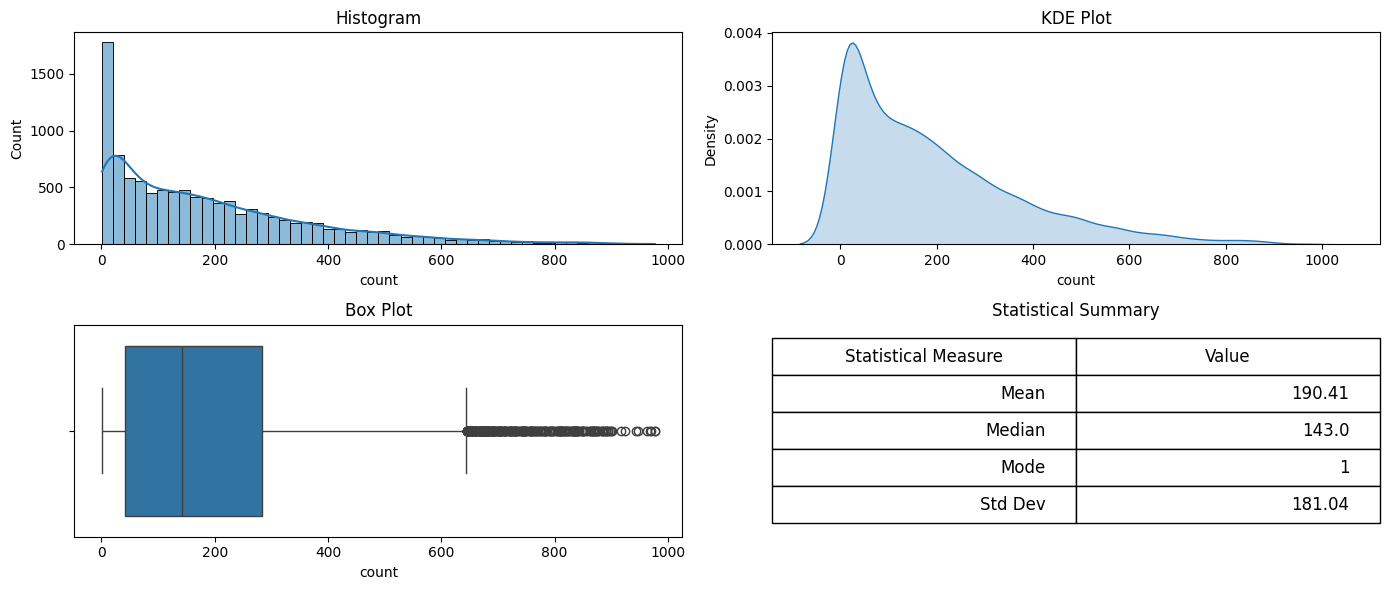

In [7]:
fig, axes = plt.subplots(2, 2, figsize=(14,6))

# Histogram
sns.histplot(train_data['count'], bins=50, kde=True, ax=axes[0,0])
axes[0,0].set_title('Histogram')

# KDE Plot
sns.kdeplot(train_data['count'], fill=True, ax=axes[0,1])
axes[0,1].set_title('KDE Plot')

# Box Plot
sns.boxplot(x=train_data['count'], ax=axes[1,0])
axes[1,0].set_title('Box Plot')

# Statistical summary
axes[1,1].axis('off')
stats_tab = [
    ['Mean', round(train_data['count'].mean(), 2)],
    ['Median', round(train_data['count'].median(), 2)],
    ['Mode', round(train_data['count'].mode()[0], 2)],
    ['Std Dev', round(train_data['count'].std(), 2)]
]
stats_table = axes[1,1].table(
    cellText=stats_tab,
    colLabels=['Statistical Measure', 'Value'],
    loc='center'
)
stats_table.auto_set_font_size(False)
stats_table.set_fontsize(12)
stats_table.scale(1, 2.2)
axes[1,1].set_title('Statistical Summary')

plt.tight_layout()
plt.show()

In [8]:
## Segerating categorical and numerical columns for better analysis of association of features with target variable
target_col = 'count'
id_cols = 'datetime'
cat_cols = ['season','holiday','workingday','weather','year','month','day','hour']
num_cols = ['temp','atemp','humidity','windspeed']

### <a id='section_3c'>3C. Relationship between categorical columns and target variable (`count`)</a>

*   Use Annova (i.e. f-statistics) for measuring strength of association

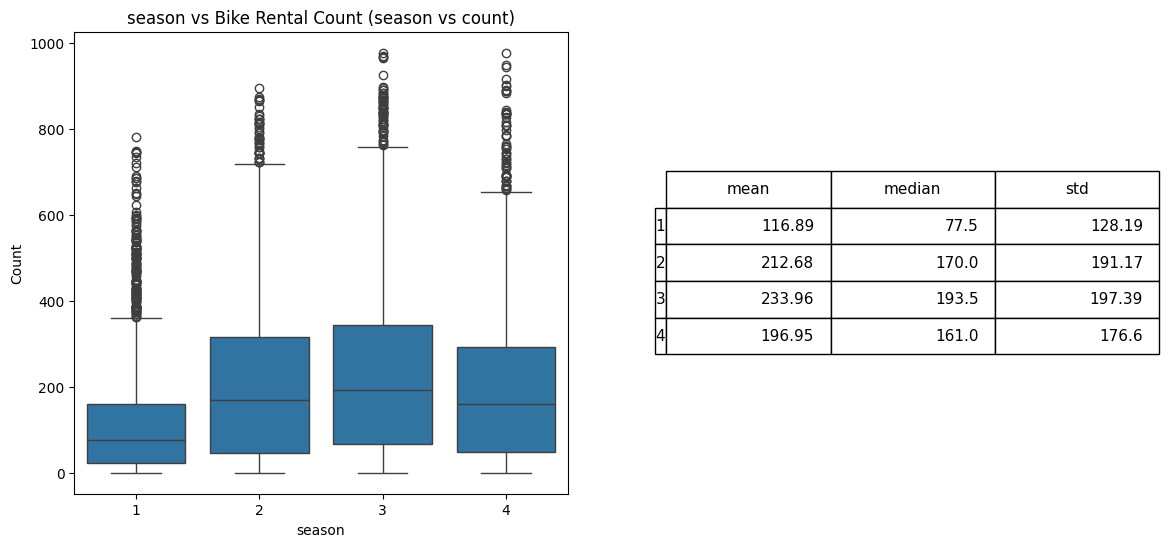

<Figure size 800x600 with 0 Axes>

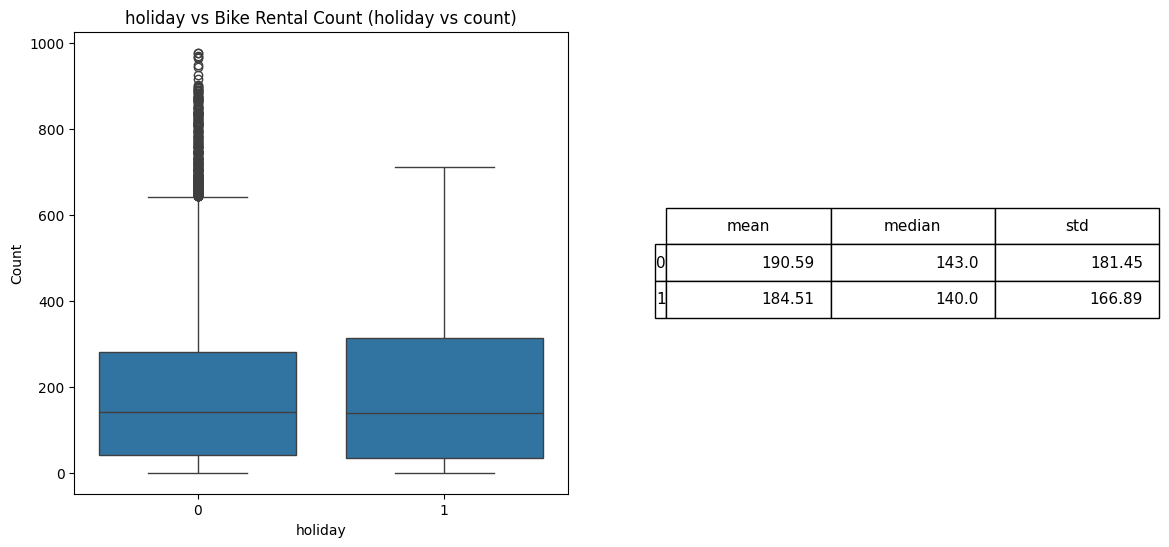

<Figure size 800x600 with 0 Axes>

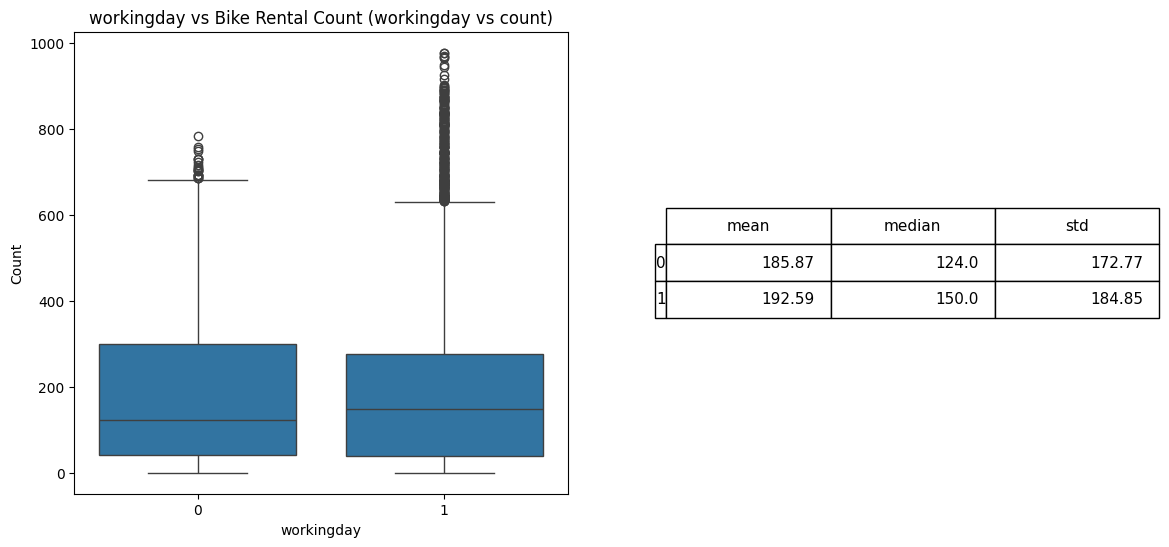

<Figure size 800x600 with 0 Axes>

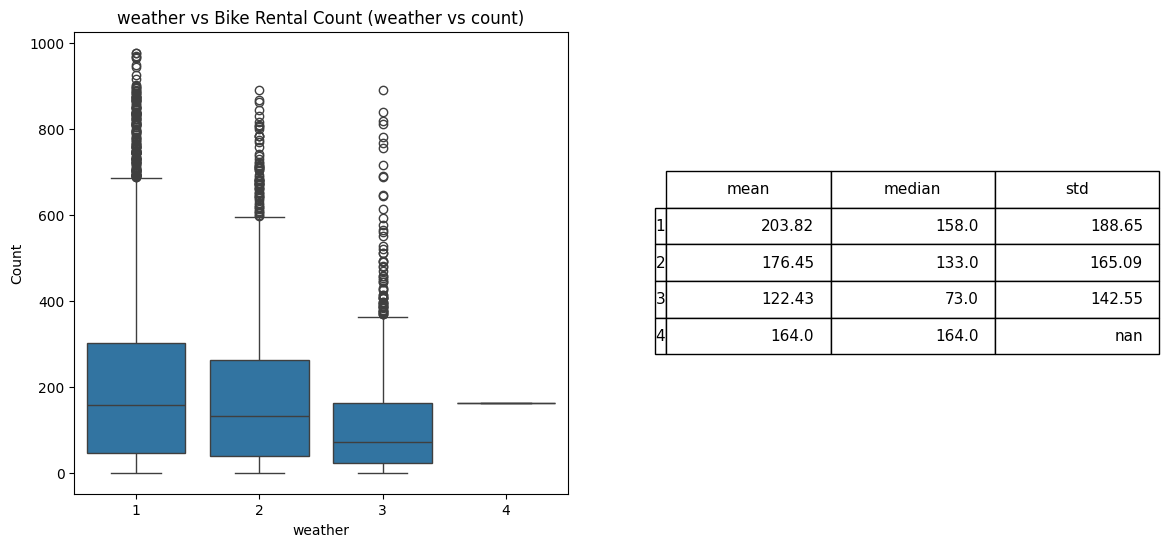

<Figure size 800x600 with 0 Axes>

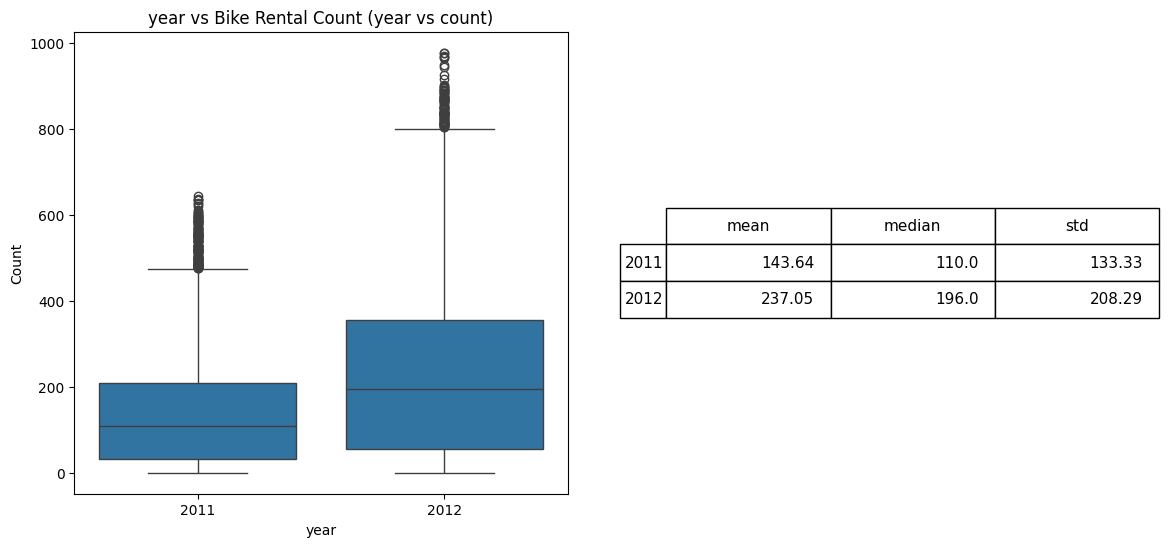

<Figure size 800x600 with 0 Axes>

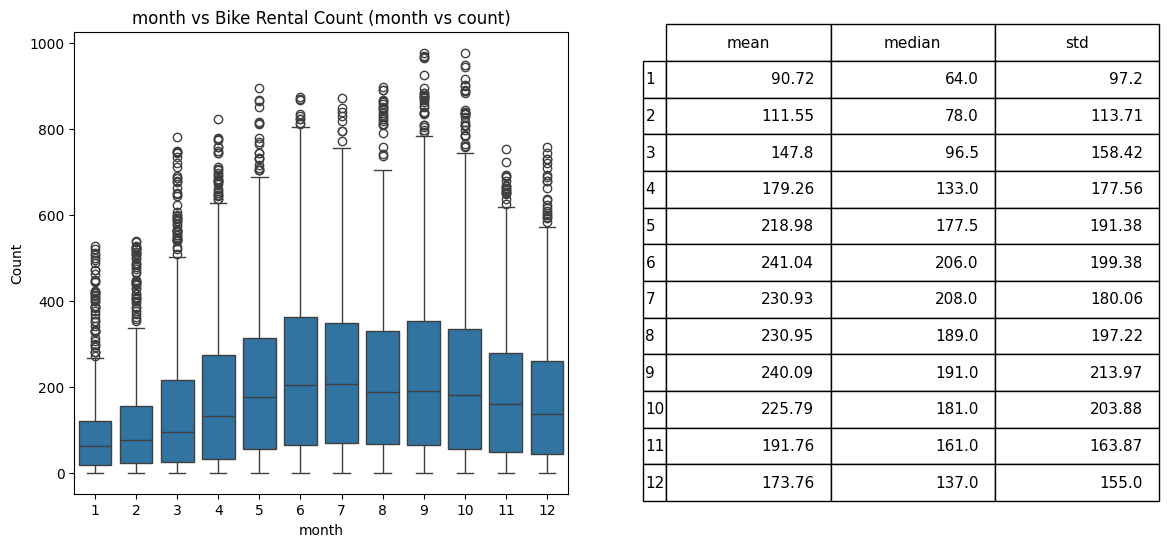

<Figure size 800x600 with 0 Axes>

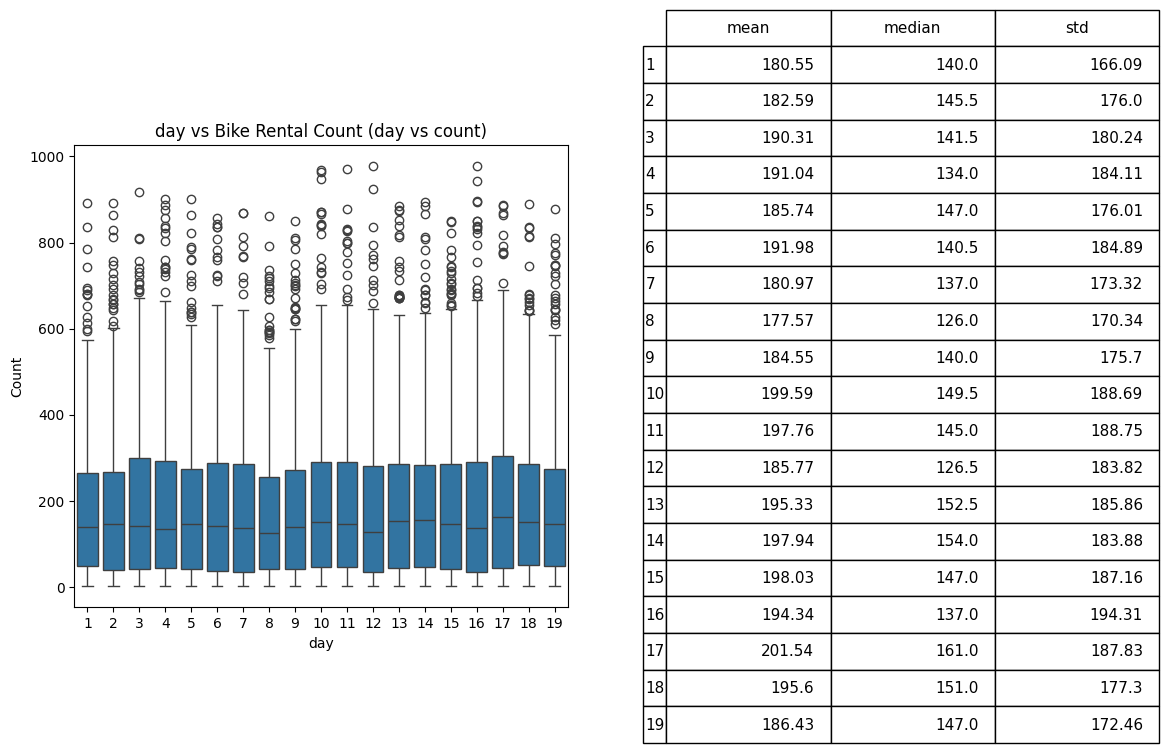

<Figure size 800x600 with 0 Axes>

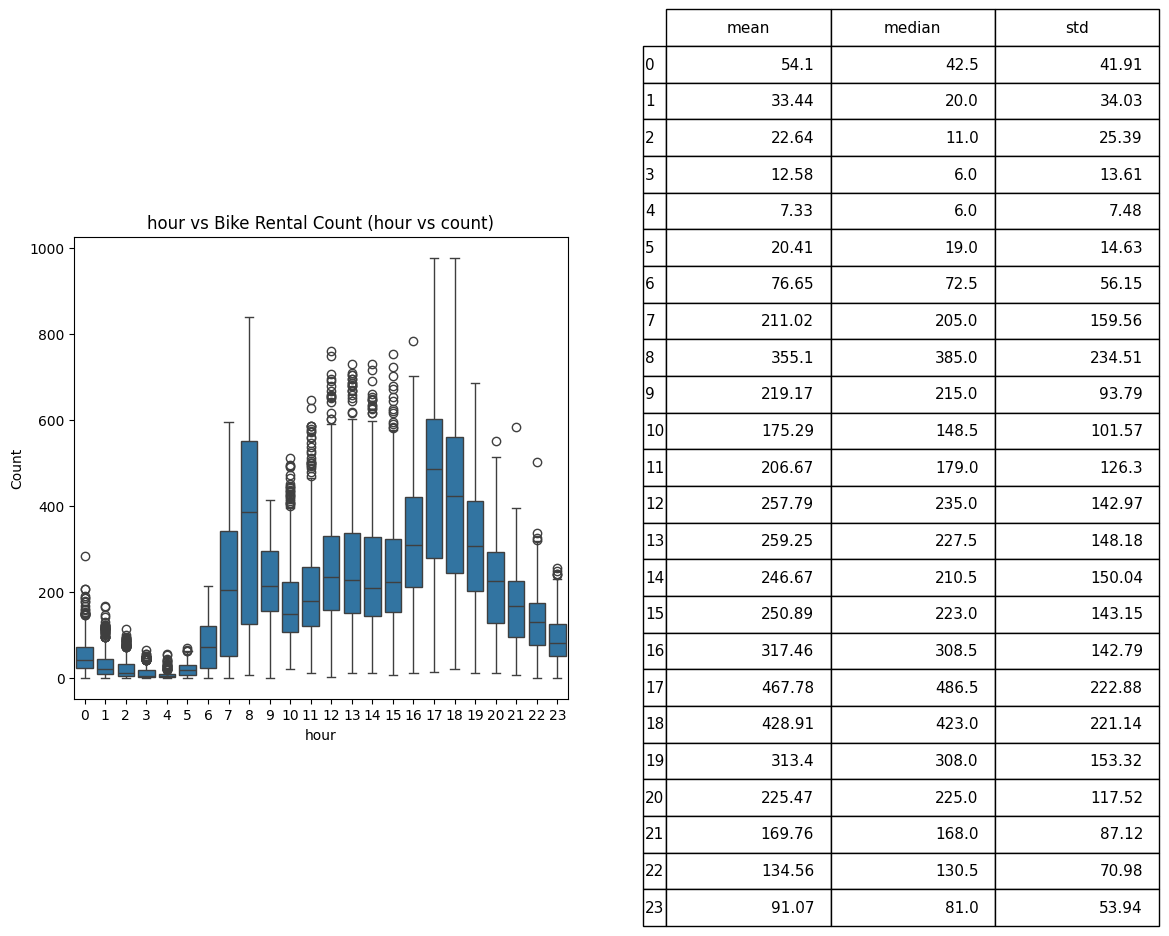

<Figure size 800x600 with 0 Axes>

In [9]:
## Plot boxplot and table of mean, median, and standard deviation for each categorical feature against the target variable 'count'
for col in cat_cols:
    fig, axes = plt.subplots(1,2, figsize=(14,6))
    plt.figure(figsize=(8,6))

    sns.boxplot(x=col, y='count', data=train_data, ax=axes[0])
    axes[0].set_title(f'{col} vs Bike Rental Count ({col} vs count)')
    axes[0].set_xlabel(col)
    axes[0].set_ylabel('Count')

    axes[1].axis('off')
    cat_stats = train_data.groupby(col)['count'].agg(['mean', 'median', 'std']).round(2)
    cat_stats_table = axes[1].table(
        cellText=cat_stats.values,
        rowLabels=cat_stats.index,
        colLabels=cat_stats.columns,
        loc='center'
    )
    cat_stats_table.auto_set_font_size(False)
    cat_stats_table.set_fontsize(11)
    cat_stats_table.scale(1, 2.2)

    plt.tight_layout()
    plt.show()

In [10]:
## Quantify the strenght of association of each categorical feature with trarget variable 'count' using ANOVA F-test and p-value
from scipy.stats import f_oneway

cat_cols_association_results = []
for col in cat_cols:
    groups = [group[target_col].values for _, group in train_data.groupby(col)]

    f_stat, p_value = f_oneway(*groups)
    cat_cols_association_results.append({
        'Feature': col,
        'F-Statistic': round(f_stat, 2),
        'P-Value': round(p_value, 6),
        'Significance': 'Strong' if p_value < 0.05 else 'Weak'
    })

cat_cols_association_df = pd.DataFrame(cat_cols_association_results)
cat_cols_association_df = cat_cols_association_df.sort_values(by='P-Value')
cat_cols_association_df

,Feature,F-Statistic,P-Value,Significance
0,season,219.97,0.000000,Strong
3,weather,57.39,0.000000,Strong
4,year,744.97,0.000000,Strong
5,month,74.00,0.000000,Strong
7,hour,484.91,0.000000,Strong
2,workingday,3.15,0.075955,Weak
1,holiday,0.33,0.566027,Weak
6,day,0.89,0.595176,Weak


### <a id='section_3d'>3D. Relationship between numerical columns and target variable (`count`)</a>

*   Use Pearson's coefficient for strength of association

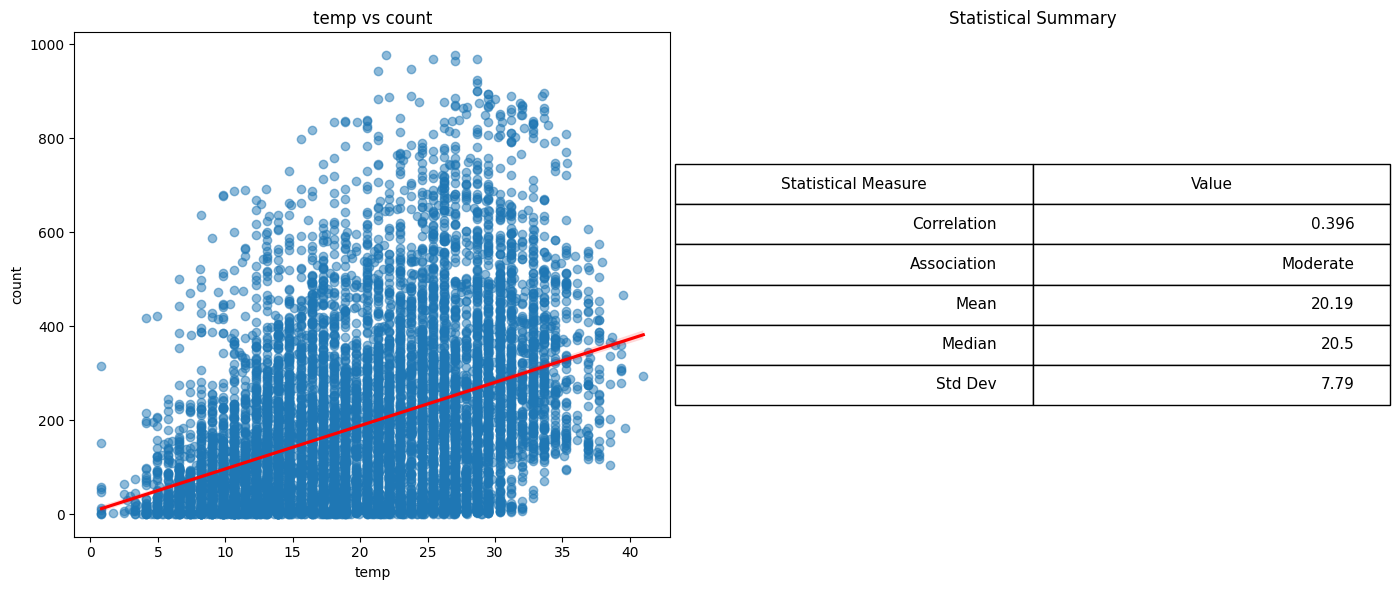

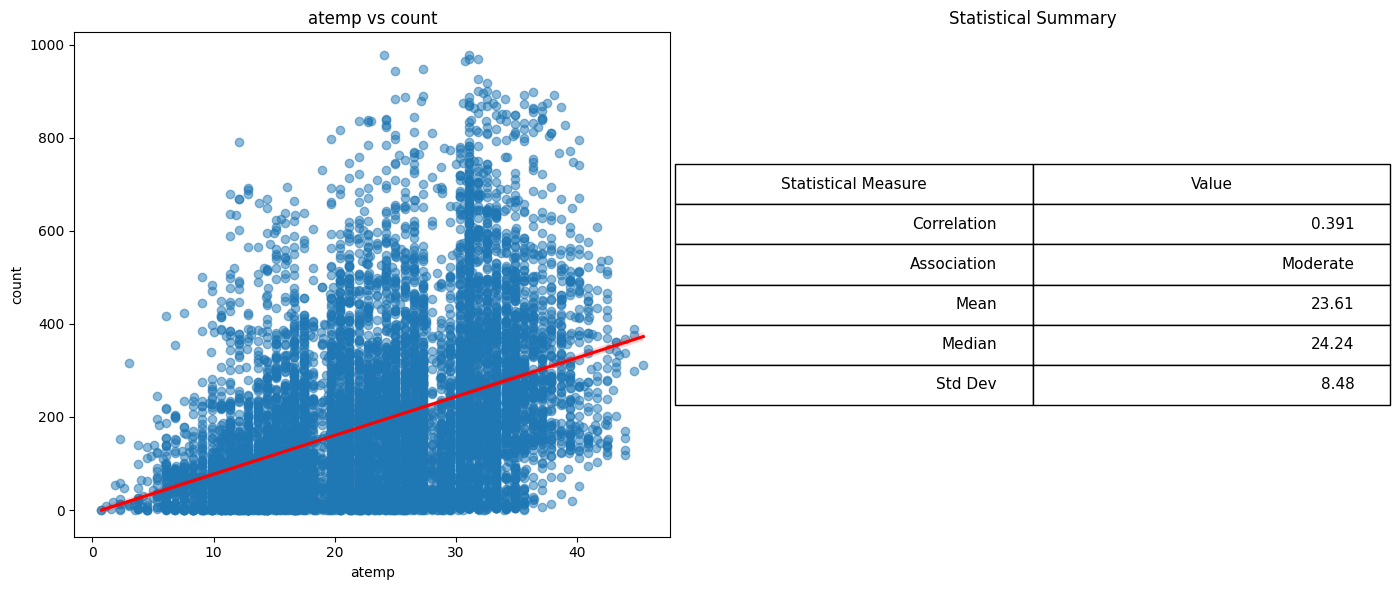

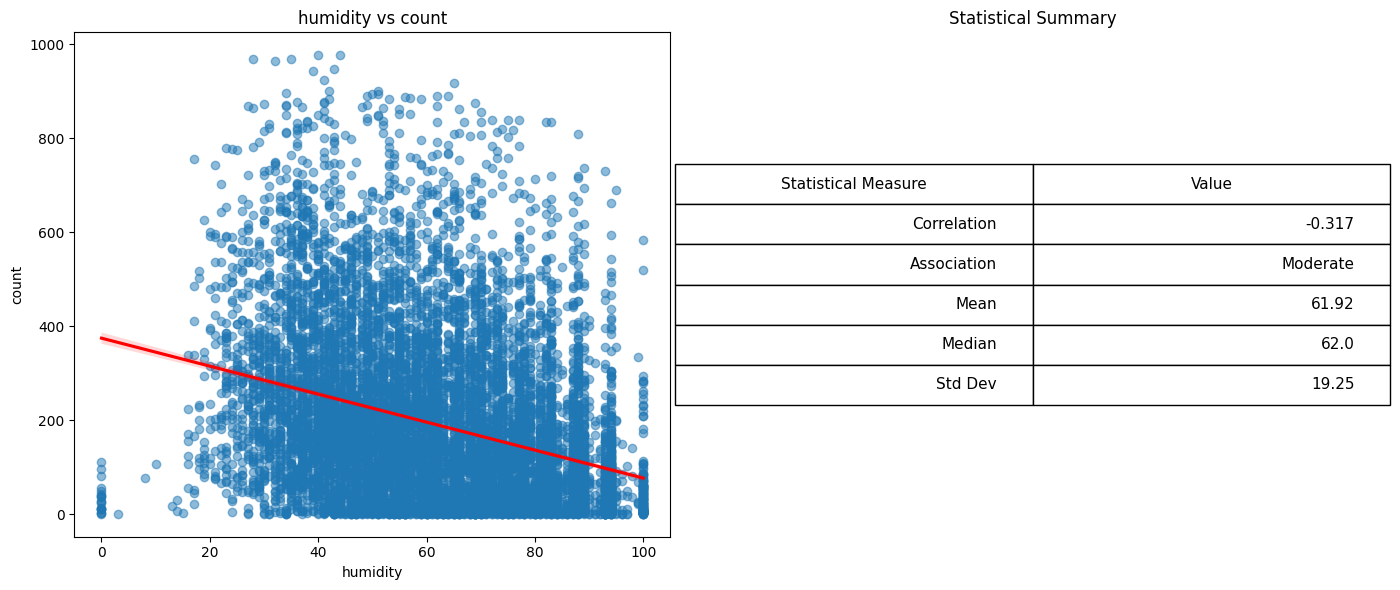

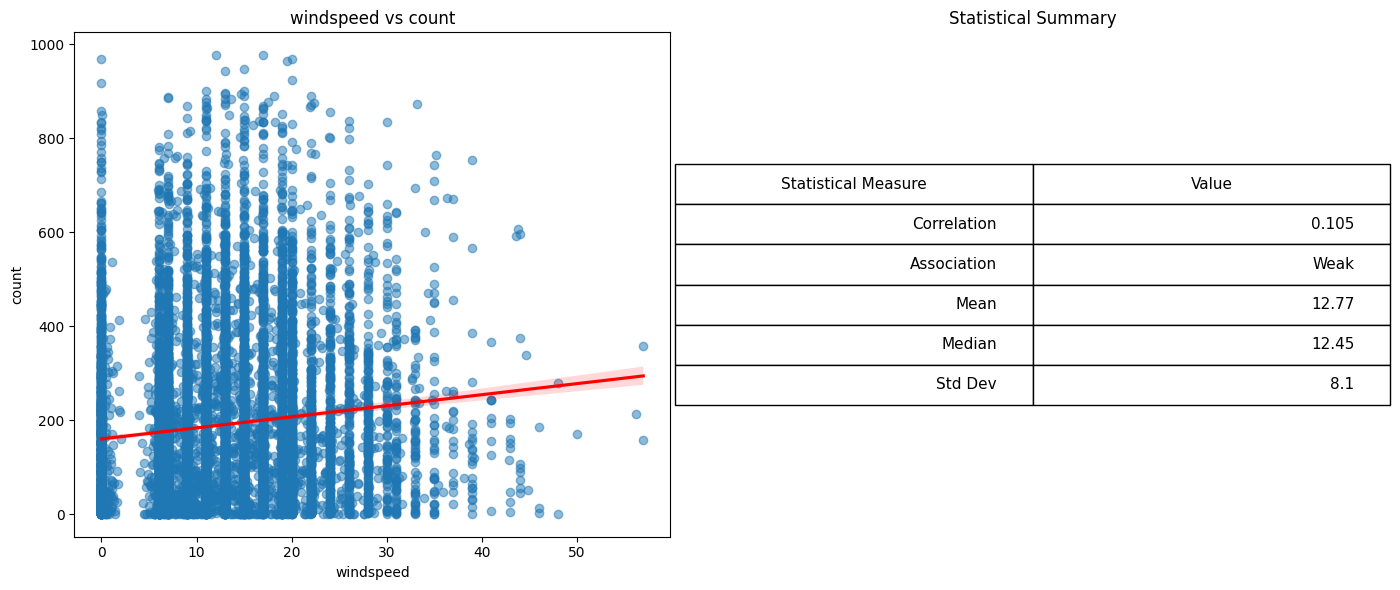

In [11]:
num_cols_association_results = []
for col in num_cols:
    fig, axes = plt.subplots(1,2, figsize=(14,6))
    sns.regplot(
        x=col,
        y=target_col,
        data=train_data,
        scatter_kws={'alpha':0.5},
        line_kws={'color':'red'},
        ax=axes[0]
    )
    axes[0].set_title(f'{col} vs {target_col}')
    corr = train_data[col].corr(train_data[target_col])
    mean_val = train_data[col].mean()
    median_val = train_data[col].median()
    std_val = train_data[col].std()

    strength = (
        'Strong'
        if abs(corr) >= 0.7 else
        'Moderate'
        if abs(corr) >= 0.3 else
        'Weak'
    )

    stats_table = pd.DataFrame({
        'Statistical Measure': [
            'Correlation',
            'Association',
            'Mean',
            'Median',
            'Std Dev'
        ],
        'Value': [
            round(corr, 3),
            strength,
            round(mean_val, 2),
            round(median_val, 2),
            round(std_val, 2)
        ]
    })

    axes[1].axis('off')

    table = axes[1].table(
        cellText=stats_table.values,
        colLabels=stats_table.columns,
        loc='center'
    )

    table.auto_set_font_size(False)
    table.set_fontsize(11)
    table.scale(1.2, 2.2)

    axes[1].set_title('Statistical Summary')

    plt.tight_layout()
    plt.show()

### <a id='section_3e'>3E. Check correlation among features.</a> 

*   `temp` vs `atemp`
*   `holiday` vs `workingday`

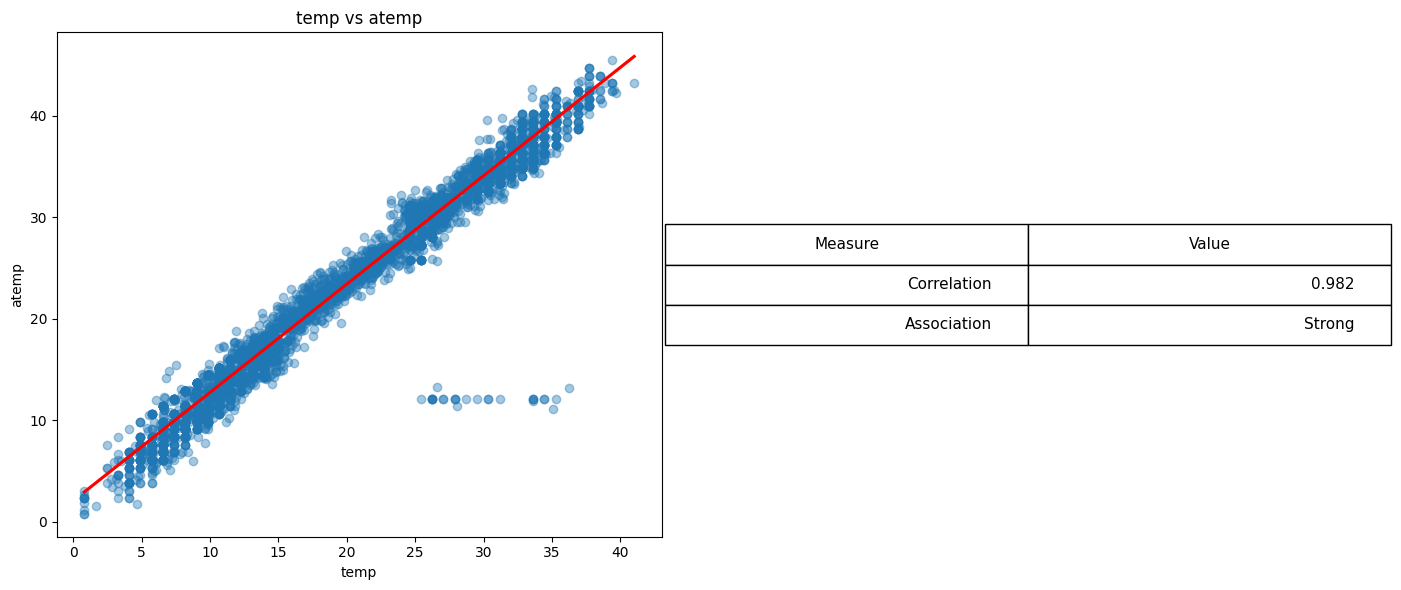

In [12]:
fig, axes = plt.subplots(1,2, figsize=(14,6))
sns.regplot(
    x='temp',
    y='atemp',
    data=train_data,
    scatter_kws={'alpha':0.4},
    line_kws={'color':'red'},
    ax=axes[0]
)

axes[0].set_title('temp vs atemp')
corr = train_data['temp'].corr(train_data['atemp'])
stats_table = pd.DataFrame({
    'Measure':['Correlation','Association'],
    'Value':[
        round(corr,3),
        'Strong' if abs(corr)>=0.7 else 'Moderate'
    ]
})

axes[1].axis('off')
table = axes[1].table(
    cellText=stats_table.values,
    colLabels=stats_table.columns,
    loc='center'
)

table.auto_set_font_size(False)
table.set_fontsize(11)
table.scale(1.2,2.2)

plt.tight_layout()
plt.show()

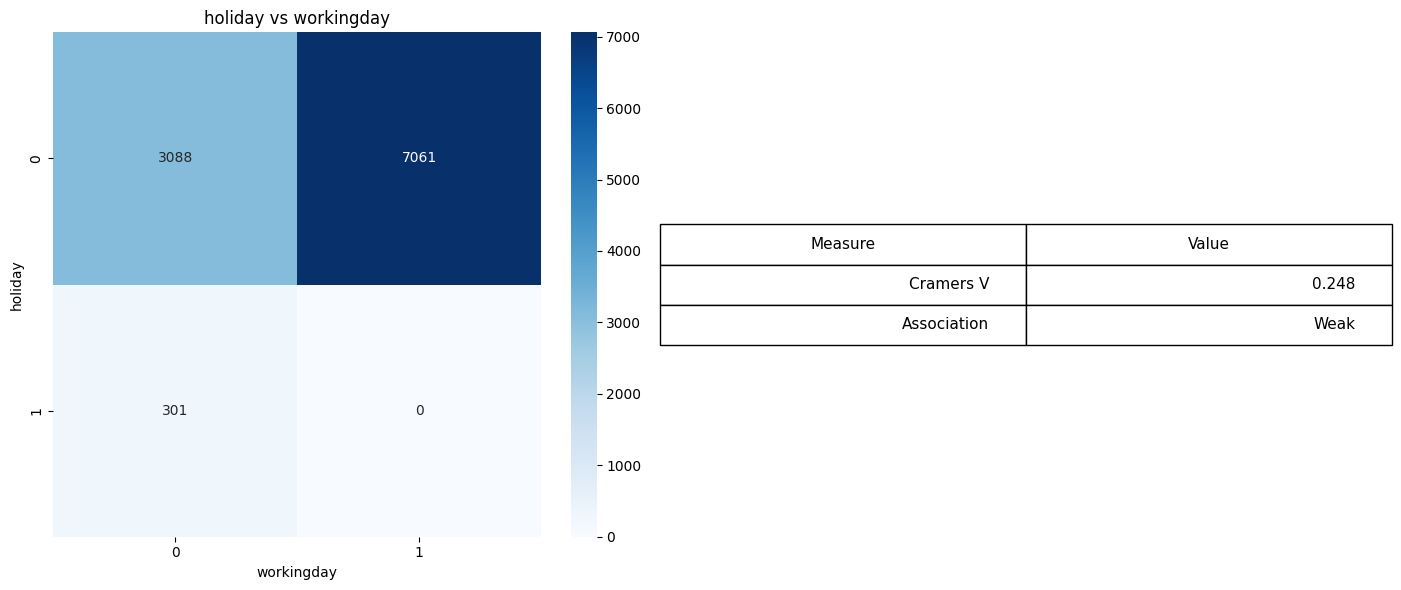

In [13]:
from scipy.stats import chi2_contingency
import numpy as np

fig, axes = plt.subplots(1,2, figsize=(14,6))
cross_tab = pd.crosstab(
    train_data['holiday'],
    train_data['workingday']
)

sns.heatmap(
    cross_tab,
    annot=True,
    fmt='d',
    cmap='Blues',
    ax=axes[0]
)

axes[0].set_title('holiday vs workingday')
chi2, p_value, _, _ = chi2_contingency(cross_tab)
n = cross_tab.sum().sum()
cramers_v = np.sqrt(
    chi2 / (n * (min(cross_tab.shape)-1))
)
stats_table = pd.DataFrame({
    'Measure':['Cramers V','Association'],
    'Value':[
        round(cramers_v,3),
        'Strong' if cramers_v>=0.5 else
        'Moderate' if cramers_v>=0.3 else
        'Weak'
    ]
})

axes[1].axis('off')
table = axes[1].table(
    cellText=stats_table.values,
    colLabels=stats_table.columns,
    loc='center'
)

table.auto_set_font_size(False)
table.set_fontsize(11)
table.scale(1.2,2.2)

plt.tight_layout()
plt.show()

### <a id='section_3f'>3F **Observations and summary**</a> 


* About whole dataset:

    * The dataset contains around 10 thousand observations and 12 columns including the target variable `count`.

    * `datetime` should be converted from string to datetime format for better time-based analysis and further feature extraction.

    * No missing values are present in the dataset.

* About association between features and target variable (`count`):

    * Both histogram and KDE plots of target variable `count` show positive skew, indicating that most bike rental counts are concentrated at lower values.

    * ANOVA F-statistics, and box plots suggest that categorical features such as `season` and `weather` have meaningful influence on the target variable.

    * Pearson correlation and regression plots indicate that temperature-related features have positive relationship with bike rental demand, while humidity shows comparatively weaker or slightly negative relationship.

    * Some relationships between features and target variable appear slightly nonlinear, indicating that simple linear relationships may not fully capture the data patterns.

* About correlations among features:

    * High correlation between `temp` and `atemp` indicates multicollinearity which may affect coefficient stability in Linear Regression models.

    * `holiday` and `workingday` also show slight association because holidays are generally non-working days.

    * Strong correlation among certain features suggests that regularization techniques may help improve model stability and generalization.

* Key insights about data:

    * Time-based, seasonal, and weather-related features appear to be the most informative predictors for bike rental demand.

    * Will use simple Linear Regression as a baseline model to understand the overall linear relationship between features and target variable.

    * As some feature relationships appear nonlinear, Polynomial Regression can also be tried to capture more complex patterns.

    * Ridge Regression may help handle multicollinearity among highly correlated numerical features, while Lasso Regression may additionally help in feature selection.

    * Time-based feature engineering such as extracting `hour`, `month`, and `weekday` from datetime and cyclic transformation of these features can improve model performance.

### Q1. Examine dataset size, missing values, and feature types.

The dataset contains approximately 10,000 observations and multiple numerical and categorical features along with the target variable `count`. No missing values were observed in the training dataset. Feature types were examined using `.info()` and `.describe()` functions.

### Q2. Visualize relationships between key features and the target variable (`count`).

Relationships between categorical and numerical features with the target variable were analyzed using box plots, and summary statistics. Weather, seasonal, and temperature-related features showed noticeable influence on bike rental demand.

### Q3. Suggest which variables are likely to be most informative.

Temperature-related variables, weather conditions, seasonal information, and time-based features such as hour and month appeared to be the most informative predictors for bike rental demand.

## <a id='section_4'>4. Feature Selection and Engineering</a> 

In [14]:
train_data.head()

,datetime,season,holiday,workingday,weather,temp,atemp,humidity,windspeed,count,year,month,day,hour
0,2012-07-15 07:00:00,3,0,0,1,28.70000,33.335000,79,6.003200,47,2012,7,15,7
1,2012-08-14 15:00:00,3,0,1,1,33.62000,37.880000,46,15.001300,283,2012,8,14,15
2,2011-02-06 06:00:00,1,0,0,1,10.66000,12.880000,60,15.001300,1,2011,2,6,6
3,2012-05-06 17:00:02,2,0,0,2,26.42506,30.566166,61,9.512288,531,2012,5,6,17
4,2012-01-09 02:00:00,1,0,1,1,9.84000,12.120000,56,8.998100,5,2012,1,9,2


In [15]:
## Apply cyclic transformation to time based features to capture their cyclical nature
def cyclic_transform(df, col, max_val):
    df[f'{col}_sin'] = np.sin(2 * np.pi * df[col] / max_val)
    df[f'{col}_cos'] = np.cos(2 * np.pi * df[col] / max_val)
    return df
time_cols = ['hour', 'day', 'month']
max_vals = {'hour': 24, 'day': 31, 'month': 12}
for col in time_cols:
    train_data = cyclic_transform(train_data, col, max_vals[col])
    del train_data[col]
train_data.head()

,datetime,season,holiday,workingday,weather,temp,atemp,humidity,windspeed,count,year,hour_sin,hour_cos,day_sin,day_cos,month_sin,month_cos
0,2012-07-15 07:00:00,3,0,0,1,28.70000,33.335000,79,6.003200,47,2012,0.965926,-2.588190e-01,0.101168,-0.994869,-0.500000,-0.866025
1,2012-08-14 15:00:00,3,0,1,1,33.62000,37.880000,46,15.001300,283,2012,-0.707107,-7.071068e-01,0.299363,-0.954139,-0.866025,-0.500000
2,2011-02-06 06:00:00,1,0,0,1,10.66000,12.880000,60,15.001300,1,2011,1.000000,6.123234e-17,0.937752,0.347305,0.866025,0.500000
3,2012-05-06 17:00:02,2,0,0,2,26.42506,30.566166,61,9.512288,531,2012,-0.965926,-2.588190e-01,0.937752,0.347305,0.500000,-0.866025
4,2012-01-09 02:00:00,1,0,1,1,9.84000,12.120000,56,8.998100,5,2012,0.500000,8.660254e-01,0.968077,-0.250653,0.500000,0.866025


In [16]:
## Delete year column as it is not relevant for the model and can lead to data leakage
del train_data['year']
train_data.head()

,datetime,season,holiday,workingday,weather,temp,atemp,humidity,windspeed,count,hour_sin,hour_cos,day_sin,day_cos,month_sin,month_cos
0,2012-07-15 07:00:00,3,0,0,1,28.70000,33.335000,79,6.003200,47,0.965926,-2.588190e-01,0.101168,-0.994869,-0.500000,-0.866025
1,2012-08-14 15:00:00,3,0,1,1,33.62000,37.880000,46,15.001300,283,-0.707107,-7.071068e-01,0.299363,-0.954139,-0.866025,-0.500000
2,2011-02-06 06:00:00,1,0,0,1,10.66000,12.880000,60,15.001300,1,1.000000,6.123234e-17,0.937752,0.347305,0.866025,0.500000
3,2012-05-06 17:00:02,2,0,0,2,26.42506,30.566166,61,9.512288,531,-0.965926,-2.588190e-01,0.937752,0.347305,0.500000,-0.866025
4,2012-01-09 02:00:00,1,0,1,1,9.84000,12.120000,56,8.998100,5,0.500000,8.660254e-01,0.968077,-0.250653,0.500000,0.866025


In [17]:
## one-hot encode categorical features for better model performance
train_data = pd.get_dummies(train_data, columns=['season','holiday','workingday','weather'], drop_first=True, dtype=int)
train_data.head()

,datetime,temp,atemp,humidity,windspeed,count,hour_sin,hour_cos,day_sin,day_cos,month_sin,month_cos,season_2,season_3,season_4,holiday_1,workingday_1,weather_2,weather_3,weather_4
0,2012-07-15 07:00:00,28.70000,33.335000,79,6.003200,47,0.965926,-2.588190e-01,0.101168,-0.994869,-0.500000,-0.866025,0,1,0,0,0,0,0,0
1,2012-08-14 15:00:00,33.62000,37.880000,46,15.001300,283,-0.707107,-7.071068e-01,0.299363,-0.954139,-0.866025,-0.500000,0,1,0,0,1,0,0,0
2,2011-02-06 06:00:00,10.66000,12.880000,60,15.001300,1,1.000000,6.123234e-17,0.937752,0.347305,0.866025,0.500000,0,0,0,0,0,0,0,0
3,2012-05-06 17:00:02,26.42506,30.566166,61,9.512288,531,-0.965926,-2.588190e-01,0.937752,0.347305,0.500000,-0.866025,1,0,0,0,0,1,0,0
4,2012-01-09 02:00:00,9.84000,12.120000,56,8.998100,5,0.500000,8.660254e-01,0.968077,-0.250653,0.500000,0.866025,0,0,0,0,1,0,0,0


In [18]:
## Typecasting all features and target variables to float for better model performance and compatibility with certain algorithms
cols_to_convert = [col for col in train_data.columns if col != 'datetime']
train_data[cols_to_convert] = train_data[cols_to_convert].astype(float)
train_data.head()

,datetime,temp,atemp,humidity,windspeed,count,hour_sin,hour_cos,day_sin,day_cos,month_sin,month_cos,season_2,season_3,season_4,holiday_1,workingday_1,weather_2,weather_3,weather_4
0,2012-07-15 07:00:00,28.70000,33.335000,79.0,6.003200,47.0,0.965926,-2.588190e-01,0.101168,-0.994869,-0.500000,-0.866025,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0
1,2012-08-14 15:00:00,33.62000,37.880000,46.0,15.001300,283.0,-0.707107,-7.071068e-01,0.299363,-0.954139,-0.866025,-0.500000,0.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0
2,2011-02-06 06:00:00,10.66000,12.880000,60.0,15.001300,1.0,1.000000,6.123234e-17,0.937752,0.347305,0.866025,0.500000,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
3,2012-05-06 17:00:02,26.42506,30.566166,61.0,9.512288,531.0,-0.965926,-2.588190e-01,0.937752,0.347305,0.500000,-0.866025,1.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0
4,2012-01-09 02:00:00,9.84000,12.120000,56.0,8.998100,5.0,0.500000,8.660254e-01,0.968077,-0.250653,0.500000,0.866025,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0


### Q4. Feature Engineering

Feature engineering techniques such as datetime decomposition, cyclical encoding of time variables, categorical encoding using one-hot encoding, and log transformation of the target variable were applied to improve model performance.

## <a id='section_5'>5. Regression Models (Model Evaluation and Selection)</a>

### UDF for evaluation of models on RMSLE, residual plot and coefficients

In [19]:
def rmsle(y_true, y_pred):
    return np.sqrt(np.mean((np.log1p(y_pred) - np.log1p(y_true))**2))

In [20]:
def evaluate_model(model,model_name,X_train,X_val,y_train,y_val,feature_names=None):

    model.fit(X_train,y_train)

    y_train_pred = model.predict(X_train)
    y_val_pred = model.predict(X_val)

    y_train_pred = np.maximum(0,y_train_pred)
    y_val_pred = np.maximum(0,y_val_pred)

    train_rmsle = rmsle(y_train,y_train_pred)
    val_rmsle = rmsle(y_val,y_val_pred)

    print(f'\n{model_name}')
    print('-'*40)
    print(f'\nTrain RMSLE: {train_rmsle:.4f}')
    print(f'Validation RMSLE: {val_rmsle:.4f}')

    y_val_actual = np.expm1(y_val)
    y_val_pred_actual = np.expm1(y_val_pred)
    residuals = y_val_actual - y_val_pred_actual

    plt.figure(figsize=(4,4))
    sns.scatterplot(x=y_val_pred_actual,y=residuals,alpha=0.5)
    plt.axhline(y=0,color='red',linestyle='--')

    plt.xlabel('Predicted Count')
    plt.ylabel('Residuals')
    plt.title(f'Residual Plot - {model_name}')
    plt.show()

    if feature_names is not None:

        coefficients_df = pd.DataFrame({
            'Feature': feature_names,
            'Coefficient': model.coef_
        })

        coefficients_df = coefficients_df.sort_values(by='Coefficient',ascending=False)
        display(coefficients_df.head(30))

    return {
        'Model': model_name,
        'Trained Model': model,
        'Hyperparameters': model.get_params(),
        'Train RMSLE': train_rmsle,
        'Validation RMSLE': val_rmsle
    }


### Split train dataset into two parts i.e. training and validation. Also scale the features for polynomial, lasso, and rdge regression models

In [21]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, PolynomialFeatures

In [22]:
X = train_data.drop(columns=[target_col,'datetime'])
y = np.log1p(train_data[target_col])

X_train,X_val,y_train,y_val = train_test_split(X,y,test_size=0.2,random_state=42)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_val_scaled = scaler.transform(X_val)

### Simple Linear Regression Model

In [23]:
from sklearn.linear_model import LinearRegression


Simple Linear Regression
----------------------------------------

Train RMSLE: 0.2222
Validation RMSLE: 0.2153


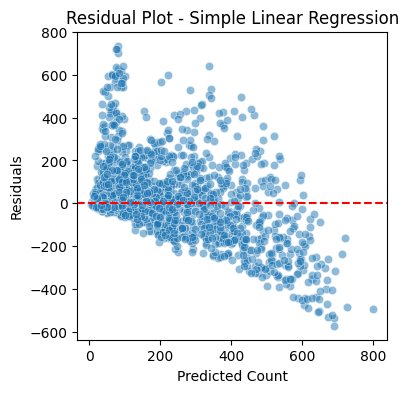

,Feature,Coefficient
12,season_4,0.214104
1,atemp,0.126832
11,season_3,0.107926
10,season_2,0.104845
0,temp,0.027228
2,humidity,0.004998
17,weather_4,0.001180
7,day_cos,-0.006420
6,day_sin,-0.008396
13,holiday_1,-0.017412


In [24]:
slr_results = evaluate_model(
    model=LinearRegression(),
    model_name='Simple Linear Regression',
    X_train=X_train_scaled,
    X_val=X_val_scaled,
    y_train=y_train,
    y_val=y_val,
    feature_names=X_train.columns
)

### **Observations and Learnings from Simple Linear Regression**

* About model performance:

    * Train and validation RMSLE scores are reasonably close, indicating that the model is not overfitting.

    * The model provides a good baseline performance but still struggles to capture more complex relationships present in the data.

* About residual analysis:

    * Residuals are comparatively more centered around zero after applying log transformation on the target variable.

    * Some visible residual patterns still exist, indicating that certain nonlinear relationships are not fully captured by the model.

* About feature coefficients:

    * Time-based, weather-related, and temperature-related features show noticeable influence on bike rental demand.

    * Correlated features such as `temp` and `atemp` may still affect coefficient stability.

* Key learnings and next steps:

    * Simple Linear Regression works reasonably well as a baseline model but has limited ability to model nonlinear patterns.

    * Since residual patterns still show structured behavior, more expressive models should be explored next.

    * Polynomial Regression can help capture nonlinear relationships between features and bike rental demand more effectively.

### Q5. Split data into training and validation sets and build a Simple Linear Regression model.

The dataset was split into training and validation sets using `train_test_split()`. A Simple Linear Regression model was trained as the baseline model and evaluated primarily using RMSLE.

### Polynomial Regression

In [25]:
poly = PolynomialFeatures(degree=3,include_bias=False)
X_train_poly = poly.fit_transform(X_train_scaled)
X_val_poly = poly.transform(X_val_scaled)
poly_feature_names = poly.get_feature_names_out(X_train.columns)


Polynomial Regression
----------------------------------------

Train RMSLE: 0.1248
Validation RMSLE: 0.1359


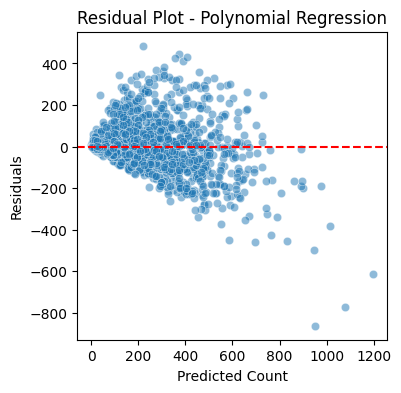

,Feature,Coefficient
216,temp atemp season_2,3.057158
215,temp atemp month_cos,1.745415
217,temp atemp season_3,1.645316
219,temp atemp holiday_1,1.225749
501,atemp holiday_1 weather_3,1.225107
463,atemp month_sin holiday_1,1.193312
442,atemp day_sin holiday_1,0.882126
207,temp atemp^2,0.843255
197,temp^2 month_sin,0.814711
220,temp atemp workingday_1,0.739254


In [26]:
poly_results = evaluate_model(
    model=LinearRegression(),
    model_name='Polynomial Regression',
    X_train=X_train_poly,
    X_val=X_val_poly,
    y_train=y_train,
    y_val=y_val,
    feature_names=poly_feature_names
)

### **Observations and Learnings from Polynomial Regression**

* About model performance:

    * Polynomial Regression significantly improved train and validation RMSLE compared to Simple Linear Regression.

    * The model achieved the best validation RMSLE among all models tested.

    * Train and validation performance remain reasonably close, indicating controlled overfitting despite increased model complexity.

* About residual analysis:

    * Residuals appear more randomly distributed around zero compared to previous models, indicating improved modeling of nonlinear relationships.

    * Variance of residuals is comparatively more stable after polynomial feature expansion.

* About feature coefficients:

    * Polynomial feature expansion introduced interaction and nonlinear terms which helped the model better capture complex relationships in bike rental demand.

    * Several interaction terms and transformed features show strong influence on predictions.

* Key learnings and next steps:

    * Significant improvement in RMSLE indicates that nonlinear relationships are important for predicting bike rental demand.

    * Polynomial feature expansion was more effective than regularization techniques in improving predictive performance.

    * This model provides the best balance between predictive performance and generalization among all models tested.

### Lasso Regression

In [27]:
from sklearn.linear_model import Lasso
from sklearn.model_selection import GridSearchCV

In [28]:
lasso_param_grid = {
    'alpha': [0.0001,0.001,0.01,0.1,1]
}

lasso_grid = GridSearchCV(
    estimator=Lasso(max_iter=10000),
    param_grid=lasso_param_grid,
    scoring='neg_mean_squared_error',
    cv=5
)

lasso_grid.fit(X_train_scaled,y_train)
best_lasso_model = lasso_grid.best_estimator_

print(lasso_grid.best_params_)

{'alpha': 0.001}



Best Lasso Regression
----------------------------------------

Train RMSLE: 0.2223
Validation RMSLE: 0.2154


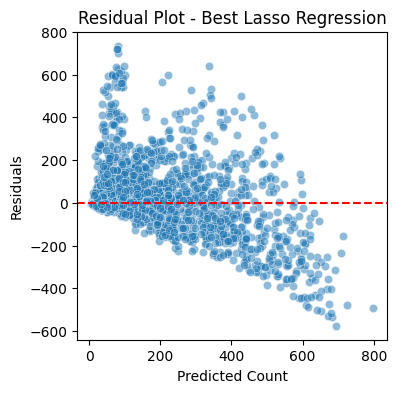

,Feature,Coefficient
12,season_4,0.206848
1,atemp,0.127870
10,season_2,0.100716
11,season_3,0.098981
0,temp,0.029612
2,humidity,0.002257
17,weather_4,0.000208
7,day_cos,-0.005729
6,day_sin,-0.007607
13,holiday_1,-0.016247


In [29]:
lasso_results = evaluate_model(
    model=best_lasso_model,
    model_name='Best Lasso Regression',
    X_train=X_train_scaled,
    X_val=X_val_scaled,
    y_train=y_train,
    y_val=y_val,
    feature_names=X_train.columns
)

### **Observations and Learnings from Lasso Regression**

* About model performance:

    * Lasso Regression produced performance similar to Simple Linear Regression across different values of regularization strength (`alpha`).

    * Hyperparameter tuning of `alpha` did not lead to meaningful improvement in validation RMSLE.

* About residual analysis:

    * Residual patterns remained similar to those observed in Simple Linear Regression, indicating that regularization alone was insufficient to capture underlying nonlinear relationships.

    * Although regularization helped simplify the model, overall prediction behavior did not improve significantly.

* About feature coefficients:

    * Lasso Regression reduced the influence of weaker features through coefficient shrinkage and automatic feature selection.

    * Some coefficients were reduced close to zero, helping simplify model complexity.

* Key learnings and next steps:

    * Results suggest that feature selection and regularization alone were insufficient to improve predictive performance substantially.

    * The primary improvement in model performance came from capturing nonlinear relationships rather than coefficient shrinkage.

    * Polynomial Regression therefore performed better than Lasso Regression for this problem.

### Ridge Regression

In [30]:
from sklearn.linear_model import Ridge

In [31]:
ridge_param_grid = {
    'alpha': [0.001,0.01,0.1,1,10,100]
}

ridge_grid = GridSearchCV(
    estimator=Ridge(),
    param_grid=ridge_param_grid,
    scoring='neg_mean_squared_error',
    cv=5
)

ridge_grid.fit(X_train_scaled,y_train)
best_ridge_model = ridge_grid.best_estimator_

print(ridge_grid.best_params_)

{'alpha': 10}



Best Ridge Regression
----------------------------------------

Train RMSLE: 0.2222
Validation RMSLE: 0.2154


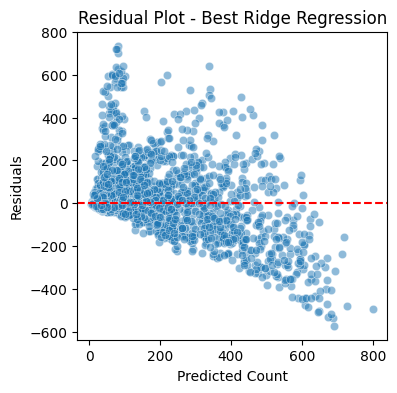

,Feature,Coefficient
12,season_4,0.212108
1,atemp,0.123812
11,season_3,0.105757
10,season_2,0.104554
0,temp,0.032581
2,humidity,0.004200
17,weather_4,0.001211
7,day_cos,-0.006433
6,day_sin,-0.008316
13,holiday_1,-0.017516


In [32]:
ridge_results = evaluate_model(
    model=best_ridge_model,
    model_name='Best Ridge Regression',
    X_train=X_train_scaled,
    X_val=X_val_scaled,
    y_train=y_train,
    y_val=y_val,
    feature_names=X_train.columns
)

### **Observations and Learnings from Ridge Regression**

* About model performance:

    * Ridge Regression produced performance very similar to Simple Linear Regression across different values of regularization strength (`alpha`).

    * Hyperparameter tuning of `alpha` did not result in significant improvement in validation RMSLE.

* About residual analysis:

    * Residual patterns remained similar to those observed in Simple Linear Regression, indicating that regularization alone did not significantly improve the model’s ability to capture nonlinear relationships.

    * Residual variance became slightly more stable due to coefficient regularization.

* About feature coefficients:

    * Ridge Regression reduced coefficient instability caused by correlated features while retaining information from most variables.

    * Regularization helped prevent excessively large coefficient values and improved coefficient stability.

* Key learnings and next steps:

    * Results indicate that multicollinearity was not the primary limitation affecting model performance.

    * The major improvement in predictive performance came from modeling nonlinear relationships rather than applying coefficient regularization.

    * Polynomial Regression therefore emerged as the best-performing model among all models tested.

### Final model comparison table

### Q6. Improve model performance using Polynomial, Ridge, and Lasso Regression.

Polynomial feature expansion (degree = 2) was used to capture nonlinear relationships. Ridge and Lasso Regression models were also applied with hyperparameter tuning of regularization strength (`alpha`) to analyze the effect of regularization on model performance.

### Q7. Summarize results of different models.

Different regression models were compared using validation RMSLE scores. Polynomial Regression achieved the best overall performance among all models tested.

### Q8. Residual plot for the best model.

Residual analysis was performed for the best-performing Polynomial Regression model to evaluate prediction behavior and identify any remaining systematic patterns in residuals.

In [33]:
model_comparison_df = pd.DataFrame([slr_results,poly_results,lasso_results,ridge_results])
model_comparison_df = model_comparison_df.sort_values(by='Validation RMSLE')

display(model_comparison_df)

,Model,Trained Model,Hyperparameters,Train RMSLE,Validation RMSLE
1,Polynomial Regression,LinearRegression(),"{'copy_X': True, 'fit_intercept': True, 'n_job...",0.124827,0.135859
0,Simple Linear Regression,LinearRegression(),"{'copy_X': True, 'fit_intercept': True, 'n_job...",0.222167,0.215342
3,Best Ridge Regression,Ridge(alpha=10),"{'alpha': 10, 'copy_X': True, 'fit_intercept':...",0.222230,0.215389
2,Best Lasso Regression,"Lasso(alpha=0.001, max_iter=10000)","{'alpha': 0.001, 'copy_X': True, 'fit_intercep...",0.222275,0.215394


* Models tested: `Simple Linear Regression`, `Polynomial Regression with degree 2`, `Lasso Regression`, and `Ridge Regression`

* Polynomial Regression with degree = 2 achieved the best validation RMSLE.

* The model performed better because it was able to capture nonlinear relationships and interaction effects between features more effectively than Simple Linear Regression, Ridge Regression, and Lasso Regression.

* Log transformation of the target variable further improved model performance by reducing skewness and stabilizing variance in bike rental counts.

* Regularization techniques such as Ridge and Lasso Regression did not provide significant improvement, indicating that nonlinear relationships were more important than multicollinearity handling for this dataset.

* Therefore, Polynomial Regression (degree = 2) was selected as the final model for generating predictions on the test dataset.

### Q9. Explain why the winning model performs better.

Polynomial Regression performed better because it was able to capture nonlinear relationships and interaction effects between features more effectively than simple linear models and regularized linear models.

## <a id='section_6'>6. Test data</a>

In [34]:
## Load test data
test_data = pd.read_csv('bike_test.csv')
test_df = test_data.copy()
test_df.head()

,datetime,season,holiday,workingday,weather,temp,atemp,humidity,windspeed
0,05-06-2012 5:00,2,0,1,3,19.680000,23.48500,82,11.00140
1,19-03-2011 19:00,1,0,0,1,18.040000,21.97000,33,19.00120
2,02-04-2012 6:00,2,0,1,1,13.885038,16.24664,68,29.52646
3,13-07-2012 20:00,3,0,1,1,30.340000,33.33500,48,8.99810
4,09-11-2011 19:00,4,0,1,1,18.040000,21.97000,72,7.00150


In [35]:
test_df.isnull().mean()

datetime      0.0
season        0.0
holiday       0.0
workingday    0.0
weather       0.0
temp          0.0
atemp         0.0
humidity      0.0
windspeed     0.0
dtype: float64

In [36]:
## Explode datetime column in test data as well to match the features used in training data
test_df['datetime'] = pd.to_datetime(test_df['datetime'],dayfirst=True)
test_df['month'] = test_df['datetime'].dt.month
test_df['day'] = test_df['datetime'].dt.day
test_df['hour'] = test_df['datetime'].dt.hour

In [37]:
for col in time_cols:
    test_df = cyclic_transform(test_df, col, max_vals[col])
    del test_df[col]

In [38]:
test_df = pd.get_dummies(test_df, columns=['season','holiday','workingday','weather'], drop_first=True, dtype=int)

In [39]:
cols_to_convert = [col for col in test_df.columns if col != 'datetime']
test_df[cols_to_convert] = test_df[cols_to_convert].astype(float)

In [40]:
X_test = test_df.drop(columns=['datetime'])
X_test = X_test.reindex(columns=X_train.columns,fill_value=0)

In [41]:
X_test_scaled = scaler.transform(X_test)
X_test_poly = poly.transform(X_test_scaled)

In [42]:
## Pick the best performing model based on validation RMSLE and use it to predict the target variable for the test data
best_poly_model = poly_results['Trained Model']

In [43]:
test_predictions_log = best_poly_model.predict(X_test_poly)

In [44]:
test_predictions = np.expm1(test_predictions_log)
test_predictions = np.maximum(test_predictions,0).astype(int)

In [45]:
test_df['count_predicted'] = test_predictions
test_df.head()

,datetime,temp,atemp,humidity,windspeed,hour_sin,hour_cos,day_sin,day_cos,month_sin,month_cos,season_2,season_3,season_4,holiday_1,workingday_1,weather_2,weather_3,count_predicted
0,2012-06-05 05:00:00,19.680000,23.48500,82.0,11.00140,0.965926,2.588190e-01,0.848644,0.528964,1.224647e-16,-1.000000e+00,1.0,0.0,0.0,0.0,1.0,0.0,1.0,22
1,2011-03-19 19:00:00,18.040000,21.97000,33.0,19.00120,-0.965926,2.588190e-01,-0.651372,-0.758758,1.000000e+00,6.123234e-17,0.0,0.0,0.0,0.0,0.0,0.0,0.0,96
2,2012-04-02 06:00:00,13.885038,16.24664,68.0,29.52646,1.000000,6.123234e-17,0.394356,0.918958,8.660254e-01,-5.000000e-01,1.0,0.0,0.0,0.0,1.0,0.0,0.0,63
3,2012-07-13 20:00:00,30.340000,33.33500,48.0,8.99810,-0.866025,5.000000e-01,0.485302,-0.874347,-5.000000e-01,-8.660254e-01,0.0,1.0,0.0,0.0,1.0,0.0,0.0,528
4,2011-11-09 19:00:00,18.040000,21.97000,72.0,7.00150,-0.965926,2.588190e-01,0.968077,-0.250653,-5.000000e-01,8.660254e-01,0.0,0.0,1.0,0.0,1.0,0.0,0.0,329


## <a id='section_7'>7. Predictions (Submission.csv)</a>


In [46]:
submission = test_df[['datetime','count_predicted']]
print(submission.shape)
submission.head()

(2613, 2)


,datetime,count_predicted
0,2012-06-05 05:00:00,22
1,2011-03-19 19:00:00,96
2,2012-04-02 06:00:00,63
3,2012-07-13 20:00:00,528
4,2011-11-09 19:00:00,329


In [47]:
submission.to_csv('submission.csv', index=False)

## <a id='section_8'>8. Assignment Questions (Q&A)</a>

### Q10. Why does RMSLE penalize under-predictions more gently than RMSE?

RMSLE reduces the impact of large absolute differences using logarithmic transformation prior to computing errors. It emphasis more on relative differences rather than raw magnitude differences.

### Q11. What are the trade-offs between model simplicity and predictive power?

Simple models such as Linear Regression are easier to interpret, faster to train, and less prone to overfitting, but they may fail to capture complex nonlinear relationships. More complex models such as Polynomial Regression improve predictive power by modeling nonlinear interactions, but they increase model complexity and risk of overfitting.

### Q12. Why can’t Linear Regression alone capture time-of-day effects effectively?

Bike rental demand changes cyclically throughout the day and does not follow a purely linear trend. Simple Linear Regression assumes linear relationships between features and target variable, so it struggles to model hourly demand peaks and nonlinear temporal patterns effectively. Polynomial features and cyclic transformations help capture these patterns better.

## THE END

* ['Back to index'](#Index)